# Probando ML de FastF1

### Instalar librerias

In [1]:
%pip install fastf1 polars pandas xgboost scikit-learn joblib

Note: you may need to restart the kernel to use updated packages.


In [2]:
!pip install pyarrow

### Ingesta

In [2]:
import os
import fastf1
import time
import pandas as pd
import logging

# Configuración de logs y cache
logging.basicConfig(level=logging.INFO)
fastf1.Cache.enable_cache('cache/')

class F1SafetyCarIngestor:
    def __init__(self):
        # Listado de circuitos callejeros para feature engineering
        self.street_circuits = ['Monaco', 'Singapore', 'Baku', 'Jeddah', 'Las Vegas', 'Melbourne', 'Miami', 'Montreal']

    def fetch_sc_history(self, years_list, output_file='dataset_sc_future.csv'):
        all_events = []
        
        for year in years_list:
            print(f"\n=== DESCARGANDO TEMPORADA {year} ===")
            try:
                schedule = fastf1.get_event_schedule(year)
                events = schedule[schedule['EventFormat'] != 'testing']
            except Exception as e:
                print(f"Error al obtener calendario {year}: {e}")
                continue

            for _, event in events.iterrows():
                try:
                    print(f"Procesando GP: {event['EventName']}")
                    session = fastf1.get_session(year, event['RoundNumber'], 'R')
                    session.load(laps=True, telemetry=False, weather=True)

                    # Identificar si hubo SC (4), VSC (6) o Red Flag (7)
                    status_presentes = session.laps['TrackStatus'].unique()
                    had_sc = 1 if any(s in status_presentes for s in ['4', '6', '7']) else 0

                    weather = session.weather_data
                    event_data = {
                        'Year': year,
                        'EventName': event['EventName'],
                        'Location': event['Location'],
                        'TrackType': 'Street' if any(s in event['EventName'] for s in self.street_circuits) else 'Permanent',
                        'AirTemp_Avg': weather['AirTemp'].mean() if not weather.empty else 25.0,
                        'TrackTemp_Avg': weather['TrackTemp'].mean() if not weather.empty else 35.0,
                        'Rainfall_Any': 1 if not weather.empty and weather['Rainfall'].any() else 0,
                        'Total_Drivers': len(session.drivers),
                        'Target_Had_SC': had_sc
                    }
                    all_events.append(event_data)
                    time.sleep(1) # Pausa de cortesía API

                except Exception as e:
                    print(f"Saltando {event['EventName']} por error: {e}")
                    continue

        df = pd.DataFrame(all_events)
        df.to_csv(output_file, index=False)
        print(f"\nGuardado exitoso: {output_file}")
        return df

# Ejecución de la descarga
ingestor = F1SafetyCarIngestor()
años = [2020, 2021, 2022, 2023, 2024]
data_raw_sc = ingestor.fetch_sc_history(años)


=== DESCARGANDO TEMPORADA 2020 ===


core           INFO 	Loading data for Austrian Grand Prix - Race [v3.8.3]
INFO:fastf1.fastf1.core:Loading data for Austrian Grand Prix - Race [v3.8.3]
req            INFO 	Using cached data for session_info
INFO:fastf1.fastf1.req:Using cached data for session_info
req            INFO 	Using cached data for driver_info
INFO:fastf1.fastf1.req:Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
INFO:fastf1.fastf1.req:Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
INFO:fastf1.fastf1.req:Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
INFO:fastf1.fastf1.req:Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
INFO:fastf1.fastf1.req:Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
INFO:fastf1.fastf1.req:Using cached data for timing_app_data
core       

Procesando GP: Austrian Grand Prix


core        WARNING 	Fixed incorrect tyre stint information for driver '99'
core        WARNING 	Driver  8: Lap timing integrity check failed for 1 lap(s)
req            INFO 	Using cached data for weather_data
INFO:fastf1.fastf1.req:Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
INFO:fastf1.fastf1.req:Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['77', '16', '4', '44', '55', '11', '10', '31', '99', '5', '6', '26', '23', '7', '63', '8', '20', '18', '3', '33']
INFO:fastf1.fastf1.core:Finished loading data for 20 drivers: ['77', '16', '4', '44', '55', '11', '10', '31', '99', '5', '6', '26', '23', '7', '63', '8', '20', '18', '3', '33']
core           INFO 	Loading data for Styrian Grand Prix - Race [v3.8.3]
INFO:fastf1.fastf1.core:Loading data for Styrian Grand Prix - Race [v3.8.3]
req            INFO 	Using cached data for session_info
INFO:fastf1.fastf1.req:Using cached data fo

Procesando GP: Styrian Grand Prix


...

Procesando GP: Qatar Grand Prix


core        WARNING 	Fixed incorrect tyre stint information for driver '43'
core        WARNING 	Fixed incorrect tyre stint information for driver '31'
req            INFO 	Using cached data for weather_data
INFO:fastf1.fastf1.req:Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
INFO:fastf1.fastf1.req:Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['1', '16', '81', '63', '10', '55', '14', '24', '20', '4', '77', '44', '22', '30', '23', '27', '11', '18', '43', '31']
INFO:fastf1.fastf1.core:Finished loading data for 20 drivers: ['1', '16', '81', '63', '10', '55', '14', '24', '20', '4', '77', '44', '22', '30', '23', '27', '11', '18', '43', '31']
core           INFO 	Loading data for Abu Dhabi Grand Prix - Race [v3.8.3]
INFO:fastf1.fastf1.core:Loading data for Abu Dhabi Grand Prix - Race [v3.8.3]
req            INFO 	Using cached data for session_info
INFO:fastf1.fastf1.req:Using cache

Procesando GP: Abu Dhabi Grand Prix


req            INFO 	Using cached data for weather_data
INFO:fastf1.fastf1.req:Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
INFO:fastf1.fastf1.req:Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['4', '55', '16', '44', '63', '1', '10', '27', '14', '81', '23', '22', '24', '18', '61', '20', '30', '77', '43', '11']
INFO:fastf1.fastf1.core:Finished loading data for 20 drivers: ['4', '55', '16', '44', '63', '1', '10', '27', '14', '81', '23', '22', '24', '18', '61', '20', '30', '77', '43', '11']



Guardado exitoso: dataset_sc_future.csv


### Ingenieria de datos

In [4]:
import polars as pl
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
import pandas as pd

# 1. CARGA Y FEATURE ENGINEERING CON POLARS
def build_ml_sc_dataset(file_path):
    # Escaneamos el archivo para procesamiento perezoso (Lazy)
    df_pl = pl.scan_csv(file_path)
    
    return (
        df_pl
        # Aseguramos tipos de datos
        .with_columns([
            pl.col("TrackType").cast(pl.Categorical),
            pl.col("Location").cast(pl.Categorical),
            pl.col("Target_Had_SC").cast(pl.Int8)
        ])
        # Calculamos la probabilidad histórica de SC por circuito (Variable clave)
        .with_columns([
            pl.col("Target_Had_SC").mean().over("Location").alias("Circuit_Risk_Score")
        ])
        # Ajustamos el riesgo si es callejero y llueve
        .with_columns([
            pl.when((pl.col("TrackType") == "Street") & (pl.col("Rainfall_Any") == 1))
            .then(pl.col("Circuit_Risk_Score") * 1.4)
            .otherwise(pl.col("Circuit_Risk_Score"))
            .alias("Adjusted_Risk")
        ])
        .collect() # Ejecutamos las operaciones
    )

dataset_sc = build_ml_sc_dataset('dataset_sc_future.csv')

# Entrenamiento

In [5]:
# 2. PREPARACIÓN PARA XGBOOST
features = ['Circuit_Risk_Score', 'Adjusted_Risk', 'TrackType', 'Rainfall_Any', 'TrackTemp_Avg']
X = dataset_sc.select(features).to_pandas()
y = dataset_sc.select("Target_Had_SC").to_pandas()

# Convertir columna de texto a categoría para el modelo
X['TrackType'] = X['TrackType'].astype('category')

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. ENTRENAMIENTO
model_sc = xgb.XGBClassifier(
    n_estimators=150,
    max_depth=5,
    learning_rate=0.05,
    enable_categorical=True,
    objective='binary:logistic'
)

model_sc.fit(X_train, y_train)

print(f"Accuracy del modelo de predicción de SC: {accuracy_score(y_test, model_sc.predict(X_test)):.2%}")

Accuracy del modelo de predicción de SC: 63.64%


### Importancia de variables

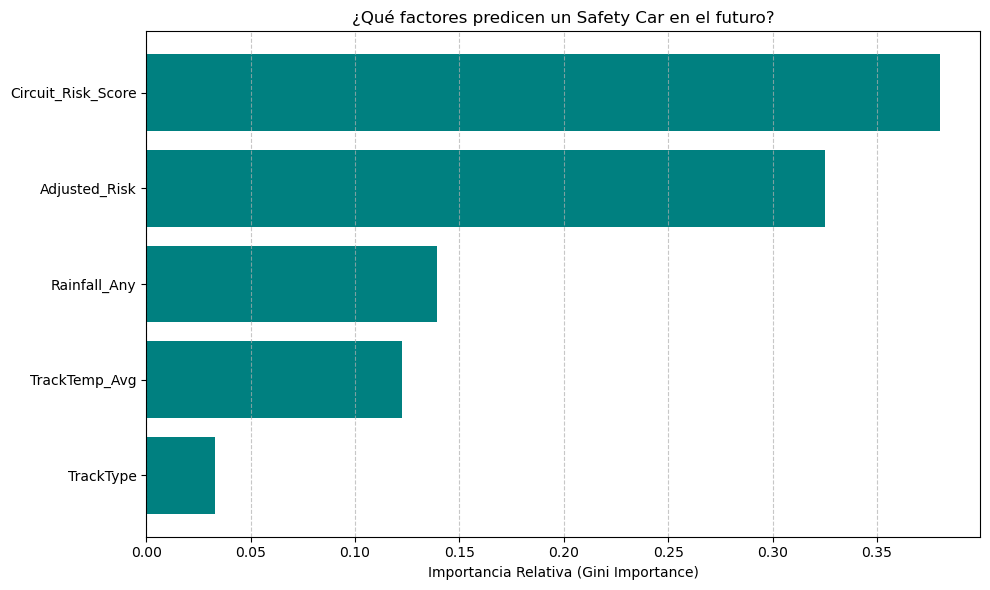

In [6]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Usamos el modelo de Safety Car (model_sc) y sus variables específicas
features_sc = ['Circuit_Risk_Score', 'Adjusted_Risk', 'TrackType', 'Rainfall_Any', 'TrackTemp_Avg']

plt.figure(figsize=(10, 6))

# Obtenemos las importancias del modelo entrenado
importances = model_sc.feature_importances_
indices = np.argsort(importances)

# Graficamos
plt.title("¿Qué factores predicen un Safety Car en el futuro?")
plt.barh(range(len(indices)), importances[indices], color='teal', align='center')
plt.yticks(range(len(indices)), [features_sc[i] for i in indices])
plt.xlabel('Importancia Relativa (Gini Importance)')
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

# PRUEBA DE CARRERA

In [15]:
def predict_future_gp_sc(location, is_street, rain_expected, temp_expected):
    # Obtener el riesgo histórico de ese circuito desde nuestro dataset Polars
    try:
        hist_risk = dataset_sc.filter(pl.col("Location") == location).select("Circuit_Risk_Score").to_series()[0]
    except:
        hist_risk = dataset_sc.select("Target_Had_SC").mean().item() # Media global si es circuito nuevo

    input_df = pd.DataFrame([{
        'Circuit_Risk_Score': hist_risk,
        'Adjusted_Risk': hist_risk * 1.4 if is_street and rain_expected else hist_risk,
        'TrackType': 'Street' if is_street else 'Permanent',
        'Rainfall_Any': 1 if rain_expected else 0,
        'TrackTemp_Avg': temp_expected
    }])
    
    input_df['TrackType'] = input_df['TrackType'].astype('category')
    prob = model_sc.predict_proba(input_df)[0][1]
    
    print(f"\n>>> PREDICCIÓN PARA GP EN {location}:")
    print(f"Probabilidad de Safety Car: {prob:.2%}")
    if prob > 0.75: print("ALTA PROBABILIDAD: Preparar estrategia de parada 'gratuita'.")

# EJEMPLO: Predicción para el GP de Jeddah con lluvia
predict_future_gp_sc("Jeddah", is_street=True, rain_expected=False, temp_expected=20.0)

# EJEMPLO: Predicción para Monza (Permanente) con calor y seco
predict_future_gp_sc("Monza", is_street=False, rain_expected=False, temp_expected=32.0)

# EJEMPLO: Predicción para Monza (Permanente) con calor y seco
predict_future_gp_sc("Monaco", is_street=True, rain_expected=False, temp_expected=32.0)


>>> PREDICCIÓN PARA GP EN Jeddah:
Probabilidad de Safety Car: 96.63%
ALTA PROBABILIDAD: Preparar estrategia de parada 'gratuita'.

>>> PREDICCIÓN PARA GP EN Monza:
Probabilidad de Safety Car: 37.12%

>>> PREDICCIÓN PARA GP EN Monaco:
Probabilidad de Safety Car: 40.81%
